Using device: cuda


C:\Users\puliu\AppData\Local\Temp\ipykernel_19992\3707338580.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=d

✅ Model loaded


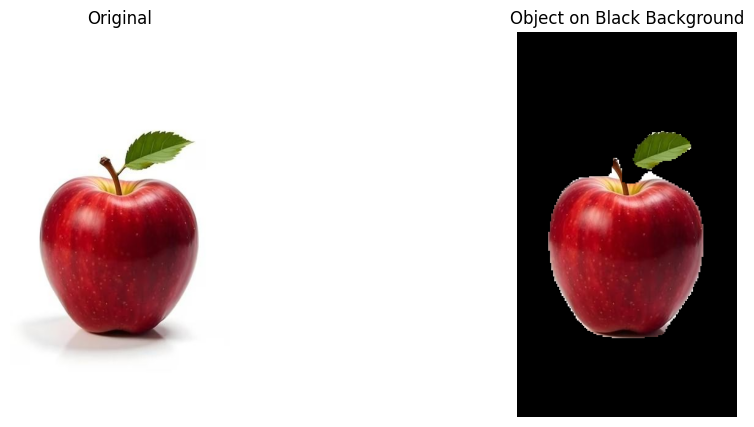

✅ Displayed: Apple Photos - Download Free High-Quality Pictures _ Freepik.jpg


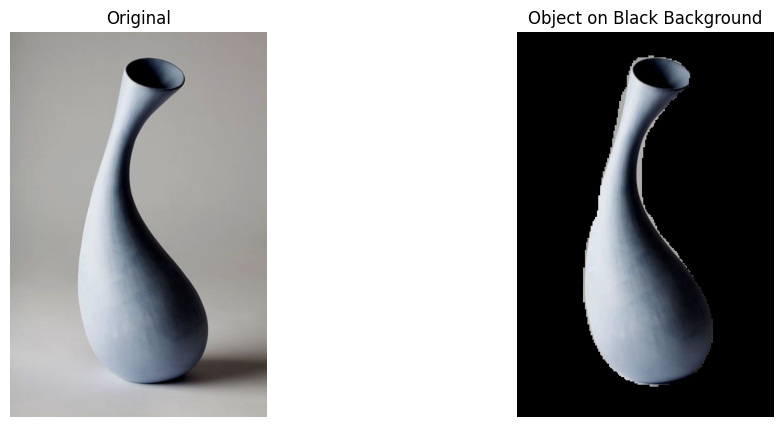

✅ Displayed: Blue Croon _ by Tina Vlassopulos.jpg


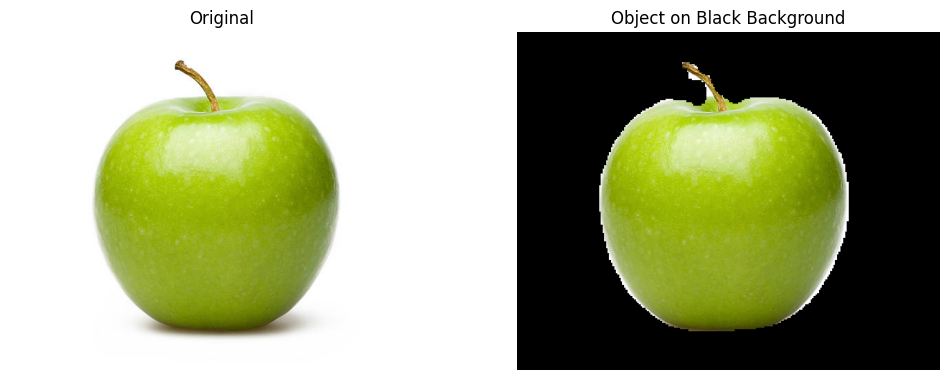

✅ Displayed: green apple.jpg


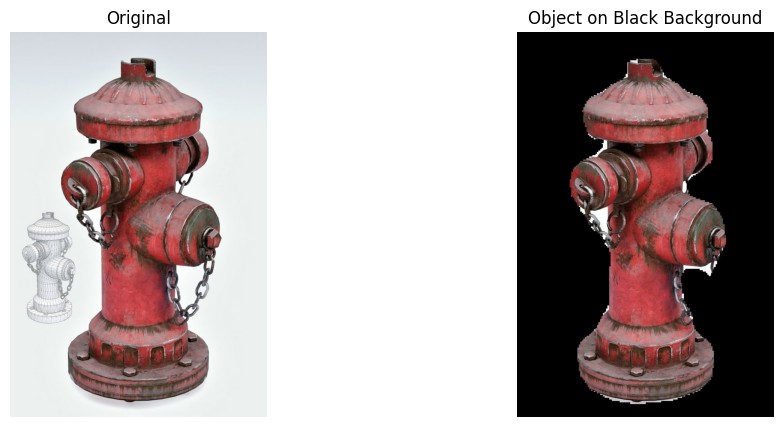

✅ Displayed: mF4PKpzg.jpg


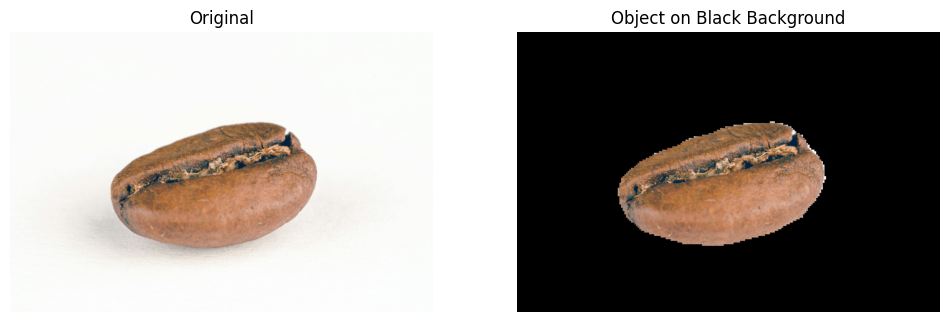

✅ Displayed: pexels-goumbik-942732.jpg


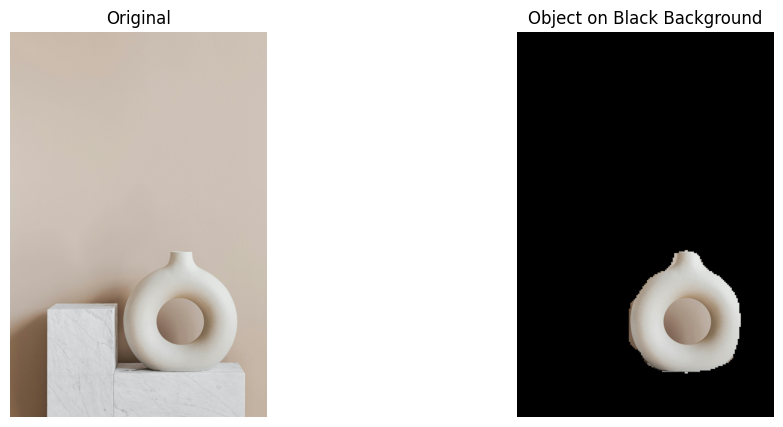

✅ Displayed: pexels-karolina-grabowska-4203100.jpg


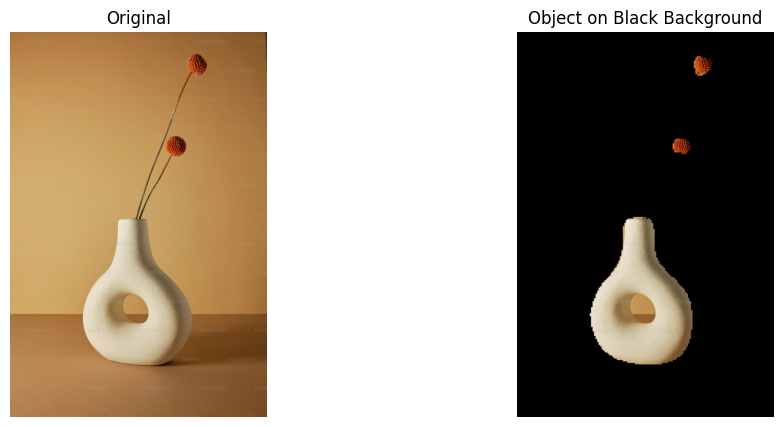

✅ Displayed: premium_photo-1668704252725-52cc74ef3f39.jpg


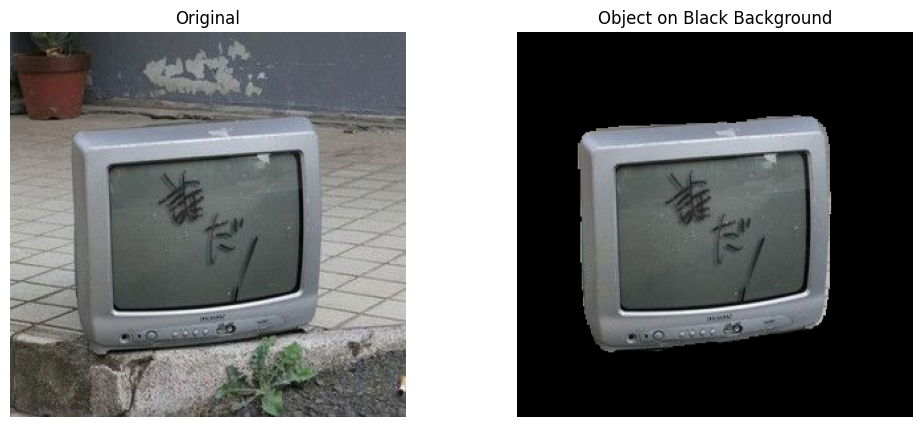

✅ Displayed: r-rosanne.jpg


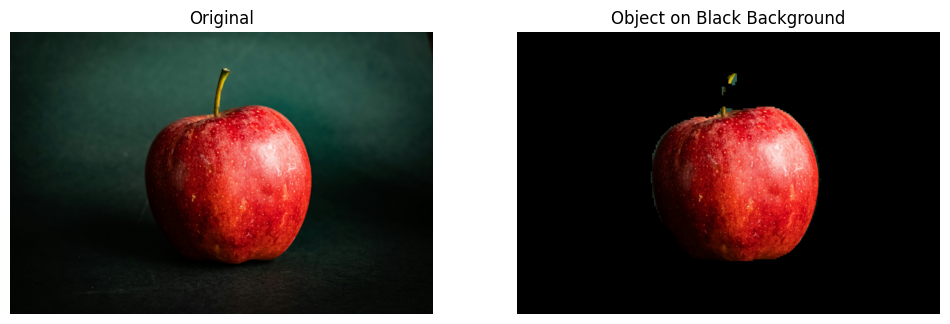

✅ Displayed: red apple.jpg


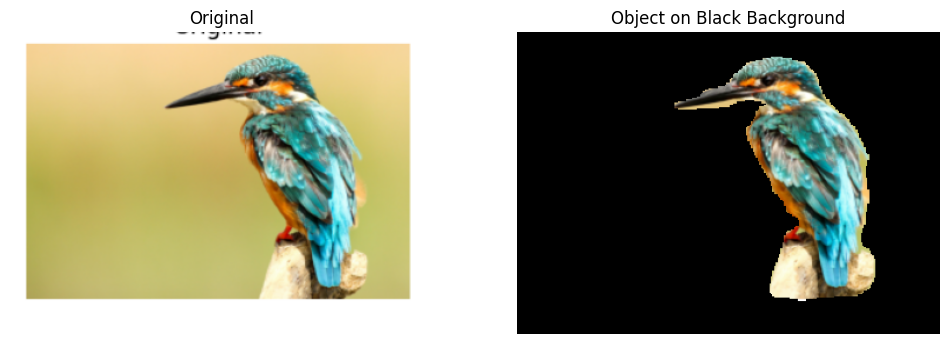

✅ Displayed: Screenshot 2025-09-30 125719.png


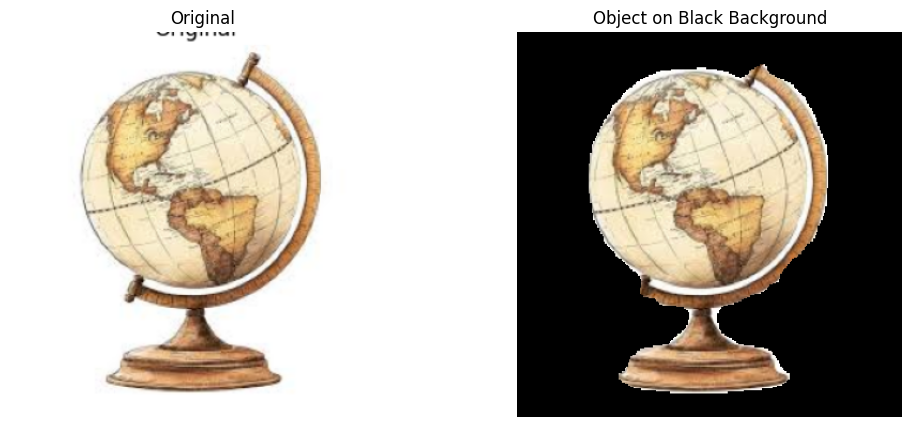

✅ Displayed: Screenshot 2025-09-30 130033.png


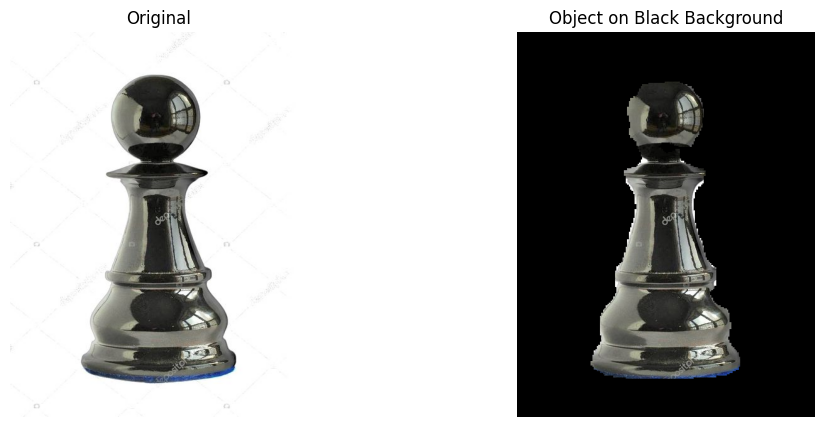

✅ Displayed: tc7xEFzN.jpg


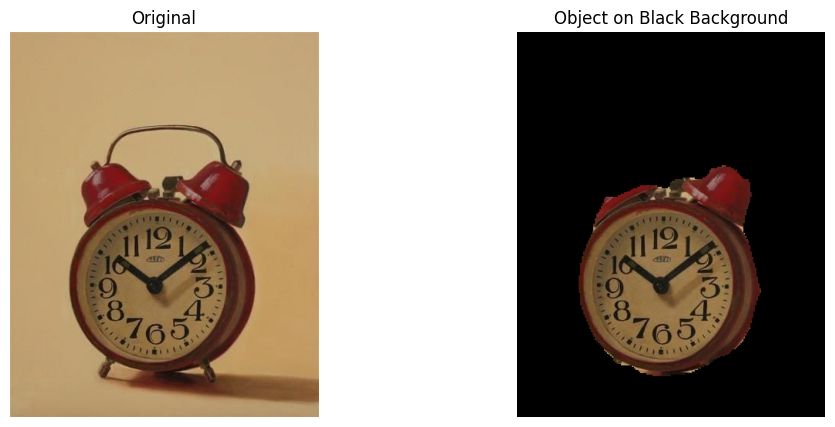

✅ Displayed: ZVnRNGFw.jpg


In [10]:
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn
# ================= Device =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# ================= Model =================
num_classes = 2
model_path = "deeplabv3_final.pth"
model = deeplabv3_resnet50(weights=None, aux_loss=True)
old_cls = model.classifier
model.classifier = nn.Sequential(
    old_cls[0], old_cls[1], old_cls[2], nn.Dropout(0.3),
    nn.Conv2d(256, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128), nn.ReLU(),
    nn.Conv2d(128, num_classes, kernel_size=1)
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()
print("✅ Model loaded")
# ================= Preprocess =================
def preprocess_image(img, long_side=256):
    h, w = img.shape[:2]
    scale = long_side / max(h, w)
    new_w, new_h = int(w*scale), int(h*scale)
    img_resized = cv2.resize(img, (new_w, new_h))
    img_tensor = torch.tensor(img_resized/255., dtype=torch.float32).permute(2,0,1).unsqueeze(0)
    mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)
    img_tensor = (img_tensor - mean) / std
    return img_tensor.to(device), (h, w)
# ================= TTA Prediction =================
def tta_predict(img_tensor):
    aug_list = [
        lambda x: x,
        lambda x: torch.flip(x, [3]),
        lambda x: torch.flip(x, [2]),
        lambda x: torch.rot90(x, k=1, dims=[2,3]),
        lambda x: torch.rot90(x, k=3, dims=[2,3])
    ]
    outputs = []
    with torch.no_grad():
        for f in aug_list:
            t = f(img_tensor)
            out = model(t)['out']
            if f != aug_list[0]:
                if f == aug_list[1]: out = torch.flip(out,[3])
                elif f == aug_list[2]: out = torch.flip(out,[2])
                elif f == aug_list[3]: out = torch.rot90(out,k=3,dims=[2,3])
                elif f == aug_list[4]: out = torch.rot90(out,k=1,dims=[2,3])
            outputs.append(out)
    return torch.mean(torch.stack(outputs), dim=0)
# ================= Post-process mask =================
def postprocess_mask(mask_tensor, orig_size):
    mask = torch.argmax(mask_tensor, dim=1).squeeze().cpu().numpy()
    mask = cv2.resize(mask.astype(np.uint8), (orig_size[1], orig_size[0]), interpolation=cv2.INTER_NEAREST)
    
    # Morphological operations to clean mask
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE,kernel)
    mask = cv2.dilate(mask,kernel,iterations=1)
    return mask
# ================= Extract Object =================
def extract_object(img, mask):
    black_bg = np.zeros_like(img)
    black_bg[mask==1] = img[mask==1]
    return black_bg
# ================= Run on Folder =================
input_folder = r"D:\external images"  # Change to your folder
for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(input_folder, filename)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Preprocess, TTA predict, post-process
        img_tensor, orig_size = preprocess_image(img)
        mask_tensor = tta_predict(img_tensor)
        pred_mask = postprocess_mask(mask_tensor, orig_size)
        # Extract object
        result = extract_object(img, pred_mask)
        # Display
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(result); plt.title("Object on Black Background"); plt.axis("off")
        plt.show()
        print(f"✅ Displayed: {filename}")
